# K-Nearest Neighbors Model

Streamlined k-NN notebook aligned with the structure used in the other model notebooks.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 1. Data Loading and Prep

In [2]:
project_root = Path.cwd()
while not (project_root / "data").exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / "data" / "processed" / "model_ready_dataset.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Dataset not found at {data_path}. "
        "Make sure you run the notebook from the repo root or run the data prep pipeline first."
    )

df = pd.read_csv(data_path)
print(f"Loaded shape: {df.shape}")

df = df[df["Prospect_Outcome"].isin(["Won", "Churned"])].copy()
df["target"] = (df["Prospect_Outcome"] == "Churned").astype(int)
df.drop(columns=["Prospect_Outcome"], inplace=True)

leaky_cols = [
    "ren_membership_renewal_decision_mode", "ren_customer_response_mode",
    "Days_To_Close_Post_Renewal", "ren_has_churn_reason",
    "Total_Net_Paid", "net_paid_vs_last", "price_change_abs", "price_change_pct",
    "Payment_Method", "Proforma_Account_Stage", "Proforma_Membership_Status",
    "Proforma_Audit_Status", "Total_Renewal_Score_New", "Tenure_Scores",
    "Sustainability_Score", "Renewal_Score_At_Release", "em_membership_level_mode",
    "em_churn_risk_signals", "em_crm_contractor_suggested_leave"
]
cols_before = set(df.columns)
df.drop(columns=leaky_cols, inplace=True, errors="ignore")
actually_dropped = cols_before - set(df.columns)
print(f"Dropped {len(actually_dropped)} leaky/non-predictive features: {sorted(actually_dropped)}")

X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01)),
])

def make_preprocessor():
    transformers = []
    if num_cols:
        transformers.append(("num", numeric_pipe, num_cols))
    if cat_cols:
        transformers.append(("cat", categorical_pipe, cat_cols))
    return ColumnTransformer(transformers, remainder="drop")

print(f"\nFeatures: {X_train.shape[1]}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Churn rate: {y_train.mean():.2%}")

Loaded shape: (122082, 61)
Dropped 19 leaky/non-predictive features: ['Days_To_Close_Post_Renewal', 'Payment_Method', 'Proforma_Account_Stage', 'Proforma_Audit_Status', 'Proforma_Membership_Status', 'Renewal_Score_At_Release', 'Sustainability_Score', 'Tenure_Scores', 'Total_Net_Paid', 'Total_Renewal_Score_New', 'em_churn_risk_signals', 'em_crm_contractor_suggested_leave', 'em_membership_level_mode', 'net_paid_vs_last', 'price_change_abs', 'price_change_pct', 'ren_customer_response_mode', 'ren_has_churn_reason', 'ren_membership_renewal_decision_mode']

Features: 41
Train: 91115, Test: 22779
Churn rate: 11.12%


## 2. Baseline KNN

In [3]:
knn_pipe_base = Pipeline([
    ("preprocess", make_preprocessor()),
    ("clf", KNeighborsClassifier(
        n_neighbors=11,
        weights="distance",
        metric="minkowski",
        p=2,
    )),
])
knn_pipe_base.fit(X_train, y_train)

y_pred_base = knn_pipe_base.predict(X_test)
y_prob_base = knn_pipe_base.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base),
    "Recall": recall_score(y_test, y_pred_base),
    "F1 Score": f1_score(y_test, y_pred_base),
    "ROC AUC": roc_auc_score(y_test, y_prob_base),
}

print("=" * 60)
print("BASELINE KNN RESULTS")
print("=" * 60)
for k, v in baseline_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=["Won", "Churned"]))

BASELINE KNN RESULTS
Accuracy  : 0.9147
Precision : 0.6484
Recall    : 0.5087
F1 Score  : 0.5701
ROC AUC   : 0.8772

              precision    recall  f1-score   support

         Won       0.94      0.97      0.95     20245
     Churned       0.65      0.51      0.57      2534

    accuracy                           0.91     22779
   macro avg       0.79      0.74      0.76     22779
weighted avg       0.91      0.91      0.91     22779



## 3. Hyperparameter Tuning

In [4]:
configs = [
    {"n_neighbors": 7, "weights": "uniform", "p": 2},
    {"n_neighbors": 9, "weights": "distance", "p": 2},
    {"n_neighbors": 11, "weights": "distance", "p": 2},
    {"n_neighbors": 15, "weights": "distance", "p": 1},
    {"n_neighbors": 21, "weights": "distance", "p": 2},
]

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
best_f1 = 0
best_config = None

for i, cfg in enumerate(configs):
    pipe = Pipeline([
        ("preprocess", make_preprocessor()),
        ("clf", KNeighborsClassifier(metric="minkowski", **cfg)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_strat, scoring="f1", n_jobs=-1)
    mean_f1 = scores.mean()
    print(f"Config {i+1}: F1={mean_f1:.4f} (+/- {scores.std():.4f})  {cfg}")
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_config = cfg

print(f"\nBest config: {best_config}")
print(f"Best CV F1:  {best_f1:.4f}")

Config 1: F1=0.5278 (+/- 0.0054)  {'n_neighbors': 7, 'weights': 'uniform', 'p': 2}
Config 2: F1=0.5655 (+/- 0.0027)  {'n_neighbors': 9, 'weights': 'distance', 'p': 2}
Config 3: F1=0.5651 (+/- 0.0050)  {'n_neighbors': 11, 'weights': 'distance', 'p': 2}
Config 4: F1=0.5827 (+/- 0.0025)  {'n_neighbors': 15, 'weights': 'distance', 'p': 1}
Config 5: F1=0.5614 (+/- 0.0009)  {'n_neighbors': 21, 'weights': 'distance', 'p': 2}

Best config: {'n_neighbors': 15, 'weights': 'distance', 'p': 1}
Best CV F1:  0.5827


## 4. Final Evaluation

In [5]:
if best_config is None or not isinstance(best_config, dict):
    warnings.warn("best_config not found - using baseline defaults. Run the tuning cell first.")
    best_config = {"n_neighbors": 11, "weights": "distance", "p": 2}

best_knn_pipe = Pipeline([
    ("preprocess", make_preprocessor()),
    ("clf", KNeighborsClassifier(metric="minkowski", **best_config)),
])
best_knn_pipe.fit(X_train, y_train)

y_pred = best_knn_pipe.predict(X_test)
y_prob = best_knn_pipe.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_prob),
}

print("=" * 60)
print("TUNED KNN RESULTS")
print("=" * 60)
for k, v in tuned_metrics.items():
    print(f"{k:<10}: {v:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Won", "Churned"]))

TUNED KNN RESULTS
Accuracy  : 0.9187
Precision : 0.6740
Recall    : 0.5221
F1 Score  : 0.5884
ROC AUC   : 0.8845

              precision    recall  f1-score   support

         Won       0.94      0.97      0.95     20245
     Churned       0.67      0.52      0.59      2534

    accuracy                           0.92     22779
   macro avg       0.81      0.75      0.77     22779
weighted avg       0.91      0.92      0.91     22779



## 5. Diagnostics

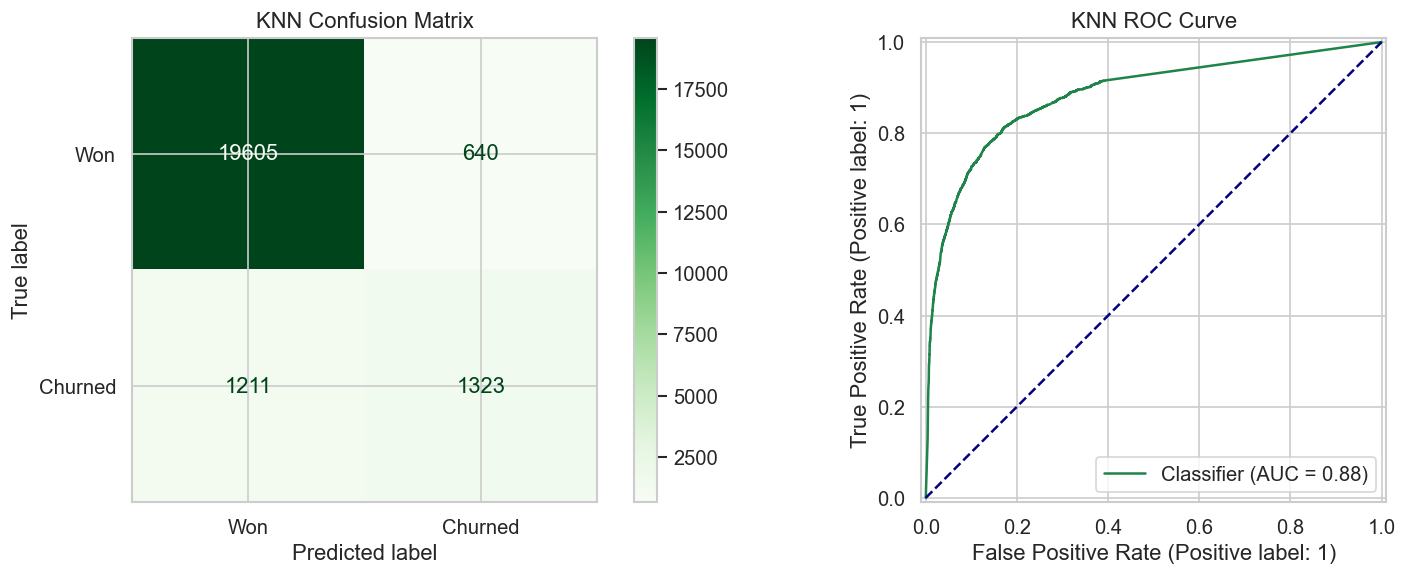

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Won", "Churned"],
    cmap="Greens",
    values_format="d",
    ax=axes[0],
)
axes[0].set_title("KNN Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_prob, color="#1e8449", ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle="--", color="navy")
axes[1].set_title("KNN ROC Curve")

plt.tight_layout()
plt.show()